In [1]:
%load_ext dotenv
%dotenv

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam

import matplotlib.pyplot as plt
import librosa as lr
import re
from pathlib import Path

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
SR = 22050
FILES = list(Path('./database/').rglob('*.wav'))

srs = set()
lengths = set()

for f in FILES:
    audio_data, sr = lr.load(f, sr=SR)
    srs.add(sr)
    lengths.add(audio_data.shape[0])

In [4]:
srs, max(lengths)  # We'll reshape our waveforms to be of this maximal length, by adding 0s to the end

({22050}, 116247)

In [5]:
MAX_LENGTH = max(lengths) # Max length of audio clips

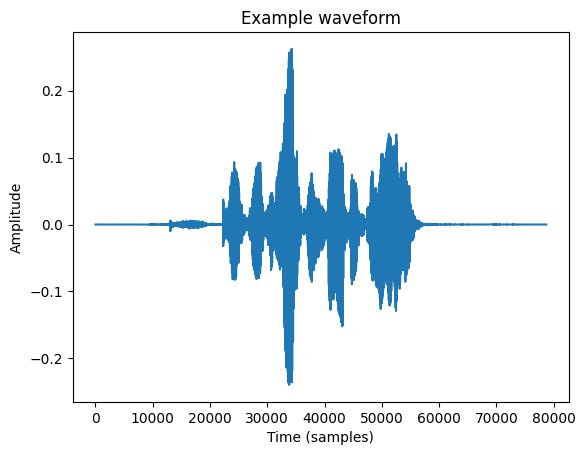

In [6]:
y_test, _ = lr.load(FILES[0], sr=SR)
plt.plot(y_test)
plt.title('Example waveform')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

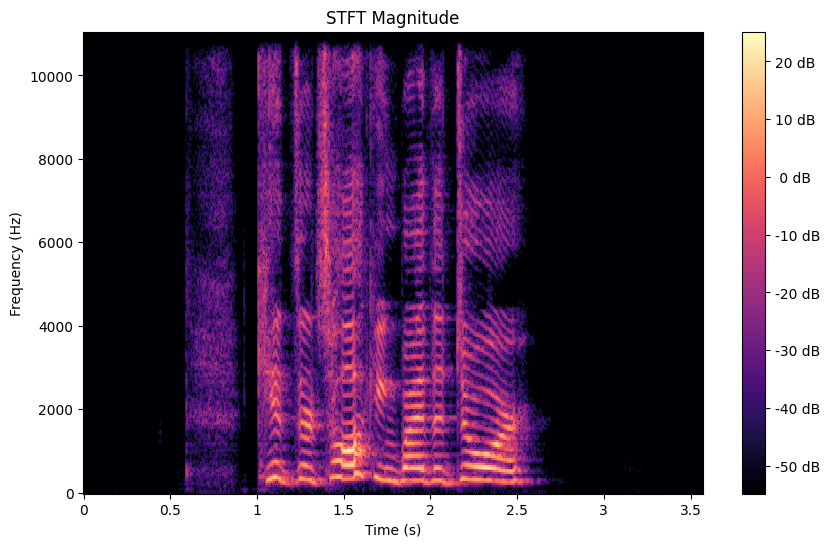

In [7]:
# Let's decompose the waveforms into their frequency components using the Short-Time Fourier Transform (STFT)
audio_data, sr = lr.load(FILES[0], sr=SR)
plt.figure(figsize=(10, 6))
D = lr.stft(audio_data, n_fft=512, hop_length=128)
lr.display.specshow(lr.amplitude_to_db(np.abs(D)), sr=sr, hop_length=128, x_axis='time', y_axis='hz')
plt.title('STFT Magnitude')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(format='%2.0f dB')
plt.show()

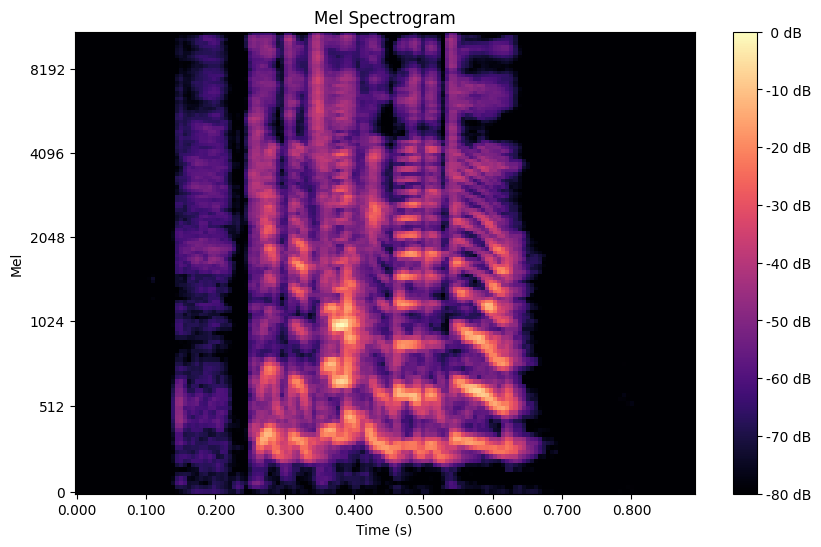

(128, 154)


In [8]:
# Let's plot the Mel spectrogram, which is a more perceptually relevant representation of the frequency content of the audio
plt.figure(figsize=(10, 6))
mel_spec = lr.feature.melspectrogram(y=audio_data, sr=SR, n_mels=128)
mel_db = lr.power_to_db(mel_spec, ref=np.max)
lr.display.specshow(mel_db, sr=SR, hop_length=128, x_axis='time', y_axis='mel')
plt.title('Mel Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Mel')
plt.colorbar(format='%2.0f dB')
plt.show()

print(mel_spec.shape)  # This is a 2D array of shape (n_mels, n_frames)

In [9]:
class AudioDataset(Dataset):
    def __init__(self, file_paths, max_length):
        self.file_paths = file_paths
        self.max_length = max_length
        super().__init__()

    def __len__(self):
        return len(self.file_paths)

    @staticmethod
    def load_audio(file: Path) -> np.ndarray:
        audio_data, sr = lr.load(file, sr=SR, mono=True)
        audio_data, _ = lr.effects.trim(audio_data)  # Remove leading and trailing silence
        if len(audio_data) < MAX_LENGTH:
            audio_data = np.pad(audio_data, (0, MAX_LENGTH - len(audio_data)), mode='constant')
        else:
            audio_data = audio_data[:MAX_LENGTH]
        mel = lr.feature.melspectrogram(
            y=audio_data,
            n_mels=128,
            n_fft=1024,
            hop_length=512,
            fmin=50,
            fmax=8000
        )
        mel_db = lr.power_to_db(mel, ref=np.max)  # Convert to decibel scale from power
        mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-9)  # Normalize to [0, 1]
        return mel_norm

    def __getitem__(self, idx):
        fname: Path = self.file_paths[idx]
        if not re.match(r'^(\d+)-(\d+)-(\d+)-(\d+)-(\d+)-(\d+)-(\d+)\.wav$', fname.name):
            raise ValueError(f"Filename {fname} does not match expected format")
        o = list(map(int, fname.stem.split('-')))
        # [modality, channel, emotion, intensity, statement, reptition, actor]
        return self.load_audio(fname), o[2] - 1  # Just return the emotion label

dataset = AudioDataset(FILES, MAX_LENGTH)

In [10]:
x, emotion = dataset[100]  # Each sample is a 1D tensor of length max_length and a 1D tensor of length 7 (the labels)
print(x.shape, emotion)

(128, 228) 5


In [11]:
def train(model, train_dataloader, val_dataloader,epochs=10):
    optimizer = Adam(model.parameters())
    criterion = nn.CrossEntropyLoss()

    L1 = len(train_dataloader)
    L2 = len(val_dataloader)

    tr_losses = []
    vl_losses = []

    for epoch in range(epochs):
        model.train()
        tr = 0
        for x, y in train_dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x.unsqueeze(1))  # Add channel dimension
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            tr += loss.item()
        tr_losses.append(tr / L1)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {tr/L1:.4f}", end=" ")
    
        model.eval()
        # Use a separate loop for validation to avoid mixing training and validation losses
        vl = 0
        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(device), y.to(device)
                outputs = model(x.unsqueeze(1))  # Add channel dimension
                loss = criterion(outputs, y)
                vl += loss.item()
        vl_losses.append(vl / L2)
        print(f"Validation Loss: {vl_losses[-1]:.4f}")

    return tr_losses, vl_losses

In [12]:
test_data, train_data, val_data = torch.utils.data.random_split(dataset, [int(0.7 * len(dataset)), int(0.2 * len(dataset)), len(dataset) - int(0.7 * len(dataset)) - int(0.2 * len(dataset))])
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True, pin_memory=True)

In [13]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            nn.Flatten(),
            nn.Linear(28672, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 8),  # 8 emotion classes
        )

    def forward(self, x):
        x = self.layers(x) # Add a channel dimension
        return x

Epoch 1/40, Loss: 2.3445 Validation Loss: 2.0627
Epoch 2/40, Loss: 2.0718 Validation Loss: 2.0562
Epoch 3/40, Loss: 2.0279 Validation Loss: 1.9945
Epoch 4/40, Loss: 1.9856 Validation Loss: 2.0222
Epoch 5/40, Loss: 1.9578 Validation Loss: 1.9590
Epoch 6/40, Loss: 1.8820 Validation Loss: 1.8870
Epoch 7/40, Loss: 1.7857 Validation Loss: 1.7543
Epoch 8/40, Loss: 1.6554 Validation Loss: 2.0289
Epoch 9/40, Loss: 1.6718 Validation Loss: 1.6439
Epoch 10/40, Loss: 1.6342 Validation Loss: 1.7123
Epoch 11/40, Loss: 1.5820 Validation Loss: 1.5388
Epoch 12/40, Loss: 1.4464 Validation Loss: 1.5909
Epoch 13/40, Loss: 1.3912 Validation Loss: 1.7214
Epoch 14/40, Loss: 1.3367 Validation Loss: 1.7751
Epoch 15/40, Loss: 1.3356 Validation Loss: 1.5794
Epoch 16/40, Loss: 1.1960 Validation Loss: 1.5354
Epoch 17/40, Loss: 1.1626 Validation Loss: 1.6172
Epoch 18/40, Loss: 1.1403 Validation Loss: 1.9868
Epoch 19/40, Loss: 1.0208 Validation Loss: 1.6148
Epoch 20/40, Loss: 0.9772 Validation Loss: 1.5543
Epoch 21/

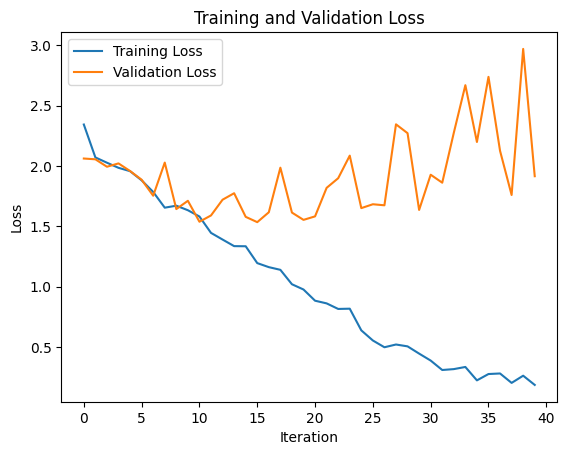

In [16]:
model = CNNClassifier().to(device)
tr_losses, vl_losses = train(model, train_dataloader, val_dataloader, epochs=40)

# Plot losses
plt.plot(tr_losses, label='Training Loss')
plt.plot(vl_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [17]:
# Test accuracy:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in test_dataloader:
        x, y = x.to(device), y.to(device)
        outputs = model(x.unsqueeze(1))  # Add channel dimension
        _, predicted = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
print(f'Test Accuracy: {correct / total:.2f}')

Test Accuracy: 0.56


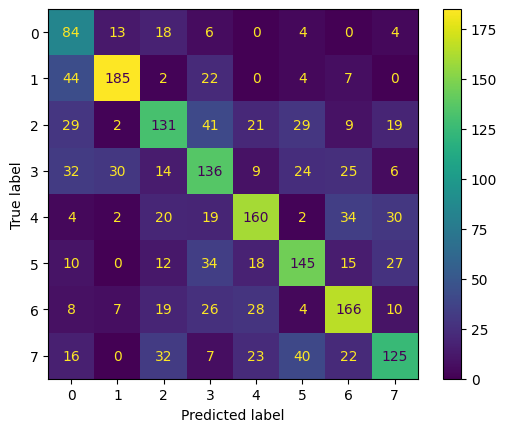

In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []
with torch.no_grad():
    for x, y in test_dataloader:
        x, y = x.to(device), y.to(device)
        outputs = model(x.unsqueeze(1))  # Add channel dimension
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
# import whisper
# model = whisper.load_model("base")

# T = {
#     f.stem: model.transcribe(f.as_posix())['text'] for f in FILES
# }

In [14]:
import json

# with open('transcripts.json', 'w') as f:
#     json.dump(T, f)

with open('transcripts.json', 'r') as f:
    T = json.load(f)

In [15]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained('openai/whisper-large-v3')
VOCAB_SIZE = tokenizer.vocab_size
print(f"Tokenizer vocab size: {VOCAB_SIZE}")

Tokenizer vocab size: 50257


In [16]:
tokenizer('Dogs are sitting by the door', return_tensors='pt')['input_ids']

tensor([[50258, 50364,    35,   664,    82,   366,  3798,   538,   264,  2853,
         50257]])

In [17]:
from transformers import AutoTokenizer


class AudioTranscriptDataset(Dataset):
    def __init__(self, transcripts):
        self.transcripts = list(transcripts.items())
        self.tokenizer = AutoTokenizer.from_pretrained('openai/whisper-large-v3')
        super().__init__()

    def __len__(self):
        return len(self.transcripts)

    def __getitem__(self, idx):
        fname, transcript = self.transcripts[idx]
        o = list(map(int, fname.split('-')))
        # [modality, channel, emotion, intensity, statement, reptition, actor]
        
        return self.tokenizer(transcript, return_tensors="pt")['input_ids'].squeeze(), o[2] - 1  # Just return the emotion label

In [18]:
def collate_fn(batch):
    # batch = [(seq_tensor_1, label_1), (seq_tensor_2, label_2), ...]
    sequences, labels = zip(*batch)     # two tuples of tensors
    padded = nn.utils.rnn.pad_sequence(
        sequences,                  # list/tuple of (T_i,) tensors
        batch_first=True,           # output shape: (B, T_max)
        padding_value=0             # PAD_IDX = 0
    )                               # → (B, T_max)

    lengths = torch.tensor([len(s) for s in sequences])  # (B,) — needed for pack_padded
    labels  = torch.stack(list(labels))                   # (B,)

    return padded, lengths, labels

In [19]:
T_dataset = AudioTranscriptDataset(T)
ttrain_dataset, tval_dataset, ttest_dataset = torch.utils.data.random_split(T_dataset, [int(0.7 * len(T_dataset)), int(0.2 * len(T_dataset)), len(T_dataset) - int(0.7 * len(T_dataset)) - int(0.2 * len(T_dataset))])
ttrain_dataloader = DataLoader(ttrain_dataset, batch_size=32, shuffle=True, pin_memory=True, collate_fn=collate_fn)
tval_dataloader = DataLoader(tval_dataset, batch_size=32, shuffle=True, pin_memory=True, collate_fn=collate_fn)
ttest_dataloader = DataLoader(ttest_dataset, batch_size=32, shuffle=True, pin_memory=True, collate_fn=collate_fn)

In [20]:
print(T_dataset[4])

(tensor([50258, 50364, 15694,   366,  1417,   538,   264,  2853,    13, 50257]), 5)


In [21]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=input_size)  # Adjust num_embeddings as needed
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        x = self.embedding(x)
        _, (hn, _) = self.rnn(x)
        out = self.fc(hn[-1])
        return out

In [22]:
RNNmodel = RNNClassifier(input_size=768, hidden_size=128, num_classes=8).to(device)
tr_losses, vl_losses = train(RNNmodel, ttrain_dataloader, tval_dataloader, epochs=40)

# Plot losses
plt.plot(tr_losses, label='Training Loss')
plt.plot(vl_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

plt.show()

TypeError: expected Tensor as element 0 in argument 0, but got int